In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx

import warnings
warnings.filterwarnings('ignore')

data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

# Load the zip code data

,Total Population,Population 0-19,geometry
ZCTA5CE20,,,
27818,1159,204,"POLYGON ((-77.16438 36.54633, -77.16432 36.546..."
27950,1918,394,"POLYGON ((-76.15427 36.54023, -76.15387 36.540..."
23128,707,126,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ..."
23314,9523,2452,"POLYGON ((-76.58686 36.93857, -76.58619 36.938..."
23462,68045,16615,"POLYGON ((-76.19498 36.83293, -76.19495 36.833..."
...,...,...,...
23878,1162,277,"POLYGON ((-77.09782 36.86998, -77.09421 36.871..."
23668,739,497,"POLYGON ((-76.34185 37.02094, -76.34181 37.021..."
23667,80,8,"POLYGON ((-76.33635 37.02244, -76.33578 37.022..."


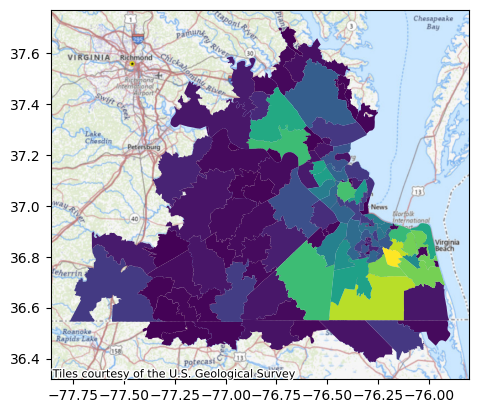

In [2]:
zcta_df = gpd.read_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations/Hampton_Roads_ZCTA_Populations.shp') \
    .rename({
        'Total Popu': 'Total Population',
        'Population': 'Population 0-19',
    }, axis=1) \
    .set_index('ZCTA5CE20')
zcta_df.plot(column='Total Population')
ctx.add_basemap(plt.gca(), source=ctx.providers.USGS.USTopo, crs=zcta_df.crs)
zcta_df

In [3]:
# Patient data and geographic region
patient_df = pd.read_csv(f'{data_dir}/Toy Project Outgoing.csv', low_memory=False, index_col='INDEX_ID')
patient_df['PATIENT_ZIPCODE'] = patient_df['PATIENT_ZIPCODE'].astype(str).str.zfill(5)
patient_df['DATE_OF_SERVICE'] = pd.to_datetime(patient_df['DATE_OF_SERVICE']).dt.to_period('D')

patient_df['DATE_OF_SERVICE'].min(), patient_df['DATE_OF_SERVICE'].max()

(Period('2018-05-01', 'D'), Period('2023-07-31', 'D'))

# Load the smoke measurement data

In [4]:
smoke_alerts = gpd.read_file(f'{data_dir}/combined_smoke_alerts/combined_smoke_alerts.shp').to_crs(zcta_df.crs)
smoke_alerts['date_local'] = pd.to_datetime(smoke_alerts['date_local'])
smoke_alerts['date_local'] = smoke_alerts['date_local'].dt.to_period('D')
smoke_alerts = smoke_alerts.set_index('date_local')

# Assign categorical column value to Density
density_dtype = pd.api.types.CategoricalDtype(categories=['None', 'Light', 'Medium', 'Heavy'], ordered=True)
smoke_alerts['Density'] = smoke_alerts['Density'].astype(density_dtype)

smoke_alerts

,Density,geometry
date_local,,
2018-05-01,Light,"MULTIPOLYGON (((-77.10177 36.54457, -77.10303 ..."
2018-05-01,None,"POLYGON ((-76.91572 36.55209, -76.91587 36.552..."
2018-05-02,Light,"MULTIPOLYGON (((-76.77884 36.82046, -76.41165 ..."
2018-05-02,None,"MULTIPOLYGON (((-77.12286 36.54411, -77.12299 ..."
2018-05-03,None,"POLYGON ((-76.91556 36.55209, -76.91572 36.552..."
...,...,...
2023-08-26,Light,"MULTIPOLYGON (((-77.09568 37.16224, -77.0939 3..."
2023-08-27,Light,"POLYGON ((-76.91587 36.55209, -76.9159 36.5520..."
2023-08-28,Light,"POLYGON ((-76.91572 36.55209, -76.91587 36.552..."


In [6]:
from tqdm.auto import tqdm

zcta_smoke = pd.DataFrame()

for date_local in tqdm(smoke_alerts.index.unique()):
    daily_smoke = smoke_alerts.loc[[date_local]]

    # Assign the highest level of smoke contained within that zip code
    daily_zcta_smoke = zcta_df.sjoin_nearest(daily_smoke, how='left') \
        .rename(columns={'Density': 'Smoke_Density'}) \
        .reset_index()
    daily_zcta_smoke = daily_zcta_smoke.groupby(['date_local', 'ZCTA5CE20']).agg({'Smoke_Density': 'max'})

    zcta_smoke = pd.concat([zcta_smoke, daily_zcta_smoke])

zcta_smoke.to_csv(f'{data_dir}/zcta_smoke_alerts.csv')
zcta_smoke

  0%|          | 0/1948 [00:00<?, ?it/s]

Smoke_Density
date_local ZCTA5CE20              
2018-05-01 23011             Light
           23030              None
           23032             Light
           23050              None
           23056              None
...                            ...
2023-08-30 27926              None
           27937              None
           27950              None
           27958              None
           27976              None

[237656 rows x 1 columns]

# Load the air quality data

Going to perform the ZCTA linkage one by one because there are some quirks to each measurement

In [7]:
air_quality = pd.read_csv(f'{data_dir}/all_fed_ref_monitor.csv', index_col=False)
air_quality = gpd.GeoDataFrame(air_quality, geometry=gpd.points_from_xy(air_quality.longitude, air_quality.latitude))
air_quality.geometry = air_quality.geometry.set_crs('EPSG:4326')
air_quality = air_quality.to_crs(zcta_df.crs)

# Create a unique site number following the AQS Site ID format
air_quality['site_number'] = air_quality['site_number'].apply(lambda x: str(x).zfill(3))
air_quality['site_number'] = air_quality[['state_code', 'county_code', 'site_number']].apply(lambda row: '-'.join(row.values.astype(str)), axis=1)

# Remove negative values and missing entries
air_quality = air_quality.loc[:, ['date_local', 'parameter', 'site_number', 'sample_measurement', 'geometry']]
air_quality = air_quality.dropna()
air_quality = air_quality[air_quality.sample_measurement >= 0]

# Collect daily average at each measurement site
air_quality['date_local'] = pd.to_datetime(air_quality['date_local']).dt.to_period('D')
air_quality = air_quality.dissolve(by=['parameter', 'site_number', 'date_local'], aggfunc='mean')
air_quality.head()

geometry  \
parameter       site_number date_local                               
Carbon monoxide 51-650-008  2018-01-01  POINT (-76.38702 37.10373)   
                            2018-01-02  POINT (-76.38702 37.10373)   
                            2018-01-03  POINT (-76.38702 37.10373)   
                            2018-01-04  POINT (-76.38702 37.10373)   
                            2018-01-05  POINT (-76.38702 37.10373)   

                                        sample_measurement  
parameter       site_number date_local                      
Carbon monoxide 51-650-008  2018-01-01            0.233333  
                            2018-01-02            0.278261  
                            2018-01-03            0.379167  
                            2018-01-04            0.258333  
                            2018-01-05            0.204348

In [8]:
air_quality.index.get_level_values(0).unique()

Index(['Carbon monoxide', 'Nitrogen dioxide (NO2)', 'Ozone',
       'PM10 Total 0-10um STP', 'PM2.5 - Local Conditions', 'Sulfur dioxide'],
      dtype='object', name='parameter')

In [9]:
from scipy.interpolate import RBFInterpolator
def rbf_interpolate(data, regions, column='sample_measurement', kernel='linear'):
    """ Interpolate source data to target points using RBF interpolation
    """
    assert data.crs == regions.crs

    # Target points 
    centroids = regions.to_crs('+proj=cea').centroid.to_crs(regions.crs)
    centroids = np.array([(point.x, point.y) for point in centroids])

    # Determine measurement points in the data
    points = np.array([(point.x, point.y) for point in data.geometry])

    # Perform RBF interpolation
    rbf = RBFInterpolator(points, data[column], kernel=kernel)
    interpolated = rbf(centroids)
    return interpolated

def interpolate_site_values_time(site_df, 
                            max_delta=7, 
                            start='2018-04-01',
                            end='2023-09-30'):
    """ Temporal interpolation of measurements to impute missing values
    """
    print(np.sum(site_df['sample_measurement'].isna()))
    site_df.index = site_df.index.to_timestamp()

    target_range = pd.date_range(start=start, end=end)
    site_full = site_df.reindex(target_range)
    site_full['geometry'] = site_full['geometry'].fillna(site_df['geometry'].iloc[0])

    site_full['sample_measurement'] = site_full['sample_measurement'].interpolate('time')
    time_deltas = site_full.index.to_series().apply(
        lambda t: np.abs((t - site_df.index[site_df.index.get_indexer([t], method='nearest')]).days)[0]
    )
    site_full['time_deltas'] = time_deltas
    
    site_full['sample_measurement'] = site_full.apply(
        lambda row: row['sample_measurement'] if abs(time_deltas[row.name]) <= max_delta else np.nan,
        axis=1
    )

    return site_full

## Carbon monixide

In [10]:
co2_df = air_quality.loc['Carbon monoxide']
co2_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-01-01  POINT (-76.38702 37.10373)            0.233333
            2018-01-02  POINT (-76.38702 37.10373)            0.278261
            2018-01-03  POINT (-76.38702 37.10373)            0.379167
            2018-01-04  POINT (-76.38702 37.10373)            0.258333
            2018-01-05  POINT (-76.38702 37.10373)            0.204348
...                                            ...                 ...
51-710-024  2023-11-10  POINT (-76.30135 36.85555)            0.133333
            2023-11-11  POINT (-76.30135 36.85555)            0.156522
            2023-11-12  POINT (-76.30135 36.85555)            0.112500
            2023-11-13  POINT (-76.30135 36.85555)            0.150000
            2023-11-14  POINT (-76.30135 36.85555)            0.146154

[4120 rows x 2 columns]

In [11]:
interpolated_df = []
for site in co2_df.index.get_level_values(0).unique():
    site_df = co2_df.loc[site]
    site_full = interpolate_site_values_time(site_df)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
             sample_measurement
site_number                    
51-650-008                   36
51-710-024                   12


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)            0.216667   
           51-710-024   POINT (-76.30135 36.85555)            0.239130   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)            0.200000   
           51-710-024   POINT (-76.30135 36.85555)            0.291304   
2018-05-03 51-650-008   POINT (-76.38702 37.10373)            0.134783   
...                                            ...                 ...   
2023-08-29 51-710-024   POINT (-76.30135 36.85555)            0.382609   
2023-08-30 51-650-008   POINT (-76.38702 37.10373)            0.200000   
           51-710-024   POINT (-76.30135 36.85555)            0.362500   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)            0.200000   
           51-710-024   POINT (-76.30135 36.85555)            0.313043   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             0  
           51-710-024             0  
2018-05-02 51-650-008             0  
           51-710-024             0  
2018-05-03 51-650-008             0  
...                             ...  
2023-08-29 51-710-024             0  
2023-08-30 51-650-008             0  
           51-710-024             0  
2023-08-31 51-650-008             0  
           51-710-024             0  

[3898 rows x 3 columns]

In [12]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'CO'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_carbon_monoxide.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                            CO  
date_local ZCTA5CE20            
2018-05-01 23011      0.217668  
           23030      0.219852  
           23032      0.216766  
           23050      0.216871  
           23056      0.217034  
...                        ...  
2023-08-31 27926      0.293521  
           27937      0.283148  
           27950      0.310141  
           27958      0.312999  
           27976      0.309904  

[237778 rows x 2 columns]

## NO2

In [13]:
no2_df = air_quality.loc['Nitrogen dioxide (NO2)']
no2_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-01-01  POINT (-76.38702 37.10373)            5.233333
            2018-01-02  POINT (-76.38702 37.10373)           10.904348
            2018-01-03  POINT (-76.38702 37.10373)           13.541667
            2018-01-04  POINT (-76.38702 37.10373)            4.595833
            2018-01-05  POINT (-76.38702 37.10373)            3.165217
...                                            ...                 ...
51-710-024  2023-12-27  POINT (-76.30135 36.85555)           12.656522
            2023-12-28  POINT (-76.30135 36.85555)           11.595833
            2023-12-29  POINT (-76.30135 36.85555)           12.247826
            2023-12-30  POINT (-76.30135 36.85555)            6.154167
            2023-12-31  POINT (-76.30135 36.85555)           10.350000

[4354 rows x 2 columns]

In [14]:
interpolated_df = []
for site in no2_df.index.get_level_values(0).unique():
    site_df = no2_df.loc[site]
    site_full = interpolate_site_values_time(site_df)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
             sample_measurement
site_number                    
51-650-008                    0
51-710-024                    0


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)            6.595833   
           51-710-024   POINT (-76.30135 36.85555)           10.547826   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)            3.822222   
           51-710-024   POINT (-76.30135 36.85555)            5.026087   
2018-05-03 51-650-008   POINT (-76.38702 37.10373)            3.118182   
...                                            ...                 ...   
2023-08-29 51-710-024   POINT (-76.30135 36.85555)            8.100000   
2023-08-30 51-650-008   POINT (-76.38702 37.10373)            2.566667   
           51-710-024   POINT (-76.30135 36.85555)            5.150000   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)            1.256522   
           51-710-024   POINT (-76.30135 36.85555)            3.230435   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             0  
           51-710-024             0  
2018-05-02 51-650-008             0  
           51-710-024             0  
2018-05-03 51-650-008             0  
...                             ...  
2023-08-29 51-710-024             0  
2023-08-30 51-650-008             0  
           51-710-024             0  
2023-08-31 51-650-008             0  
           51-710-024             0  

[3898 rows x 3 columns]

In [15]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'NO2'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_nitrogen_dioxide.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                           NO2  
date_local ZCTA5CE20            
2018-05-01 23011      6.771968  
           23030      7.156197  
           23032      6.613310  
           23050      6.631789  
           23056      6.660524  
...                        ...  
2023-08-31 27926      2.889539  
           27937      2.708411  
           27950      3.179751  
           27958      3.229656  
           27976      3.175616  

[237778 rows x 2 columns]

## Ozone

In [16]:
o3_df = air_quality.loc['Ozone']
o3_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-03-01  POINT (-76.38702 37.10373)            0.021250
            2018-03-02  POINT (-76.38702 37.10373)            0.041375
            2018-03-03  POINT (-76.38702 37.10373)            0.041696
            2018-03-04  POINT (-76.38702 37.10373)            0.040792
            2018-03-05  POINT (-76.38702 37.10373)            0.038708
...                                            ...                 ...
51-800-005  2023-10-27  POINT (-76.73078 36.66525)            0.023391
            2023-10-28  POINT (-76.73078 36.66525)            0.022292
            2023-10-29  POINT (-76.73078 36.66525)            0.019917
            2023-10-30  POINT (-76.73078 36.66525)            0.026261
            2023-10-31  POINT (-76.73078 36.66525)            0.021792

[4361 rows x 2 columns]

In [17]:
interpolated_df = []
for site in o3_df.index.get_level_values(0).unique():
    site_df = o3_df.loc[site]
    site_full = interpolate_site_values_time(site_df)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
0
             sample_measurement
site_number                    
51-650-008                  533
51-800-004                  531
51-800-005                  537


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)            0.045458   
           51-800-004   POINT (-76.43808 36.90118)            0.044042   
           51-800-005   POINT (-76.73078 36.66525)            0.038043   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)            0.051783   
           51-800-004   POINT (-76.43808 36.90118)            0.050130   
...                                            ...                 ...   
2023-08-30 51-800-004   POINT (-76.43808 36.90118)            0.026292   
           51-800-005   POINT (-76.73078 36.66525)            0.020875   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)            0.035304   
           51-800-004   POINT (-76.43808 36.90118)            0.034087   
           51-800-005   POINT (-76.73078 36.66525)            0.028261   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             0  
           51-800-004             0  
           51-800-005             0  
2018-05-02 51-650-008             0  
           51-800-004             0  
...                             ...  
2023-08-30 51-800-004             0  
           51-800-005             0  
2023-08-31 51-650-008             0  
           51-800-004             0  
           51-800-005             0  

[5847 rows x 3 columns]

In [18]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'O3'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_ozone.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                            O3  
date_local ZCTA5CE20            
2018-05-01 23011      0.043354  
           23030      0.041940  
           23032      0.044079  
           23050      0.044975  
           23056      0.045150  
...                        ...  
2023-08-31 27926      0.029383  
           27937      0.028388  
           27950      0.032726  
           27958      0.032117  
           27976      0.031189  

[237778 rows x 2 columns]

## SO2

In [19]:
so2_df = air_quality.loc['Sulfur dioxide']
so2_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-01-01  POINT (-76.38702 37.10373)            0.931410
            2018-01-02  POINT (-76.38702 37.10373)            4.210508
            2018-01-03  POINT (-76.38702 37.10373)            0.583654
            2018-01-04  POINT (-76.38702 37.10373)            2.538264
            2018-01-05  POINT (-76.38702 37.10373)            0.353741
...                                            ...                 ...
51-710-024  2023-12-27  POINT (-76.30135 36.85555)            0.184539
            2023-12-28  POINT (-76.30135 36.85555)            0.125333
            2023-12-29  POINT (-76.30135 36.85555)            0.249655
            2023-12-30  POINT (-76.30135 36.85555)            0.243322
            2023-12-31  POINT (-76.30135 36.85555)            0.418590

[4324 rows x 2 columns]

In [20]:
interpolated_df = []
for site in so2_df.index.get_level_values(0).unique():
    site_df = so2_df.loc[site]
    site_full = interpolate_site_values_time(site_df)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
             sample_measurement
site_number                    
51-650-008                    0
51-710-024                    0


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)            0.620192   
           51-710-024   POINT (-76.30135 36.85555)            0.592384   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)            0.823509   
           51-710-024   POINT (-76.30135 36.85555)            0.361356   
2018-05-03 51-650-008   POINT (-76.38702 37.10373)            1.243234   
...                                            ...                 ...   
2023-08-29 51-710-024   POINT (-76.30135 36.85555)            0.674679   
2023-08-30 51-650-008   POINT (-76.38702 37.10373)            0.691987   
           51-710-024   POINT (-76.30135 36.85555)            0.648397   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)            0.619064   
           51-710-024   POINT (-76.30135 36.85555)            0.661409   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             0  
           51-710-024             0  
2018-05-02 51-650-008             0  
           51-710-024             0  
2018-05-03 51-650-008             0  
...                             ...  
2023-08-29 51-710-024             0  
2023-08-30 51-650-008             0  
           51-710-024             0  
2023-08-31 51-650-008             0  
           51-710-024             0  

[3898 rows x 3 columns]

In [21]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'SO2'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_sulfur_dioxide.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                           SO2  
date_local ZCTA5CE20            
2018-05-01 23011      0.618953  
           23030      0.616249  
           23032      0.620069  
           23050      0.619939  
           23056      0.619737  
...                        ...  
2023-08-31 27926      0.654096  
           27937      0.650211  
           27950      0.660322  
           27958      0.661393  
           27976      0.660233  

[237778 rows x 2 columns]

## PM2.5

In [22]:
pm25_df = air_quality.loc['PM2.5 - Local Conditions']
pm25_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-01-01  POINT (-76.38702 37.10373)            5.881818
            2018-01-02  POINT (-76.38702 37.10373)            9.240000
            2018-01-03  POINT (-76.38702 37.10373)           11.720833
            2018-01-04  POINT (-76.38702 37.10373)            7.622727
            2018-01-05  POINT (-76.38702 37.10373)            4.156000
...                                            ...                 ...
51-810-008  2023-12-27  POINT (-76.18123 36.84188)            4.030435
            2023-12-28  POINT (-76.18123 36.84188)            4.575000
            2023-12-29  POINT (-76.18123 36.84188)            8.870833
            2023-12-30  POINT (-76.18123 36.84188)            3.920833
            2023-12-31  POINT (-76.18123 36.84188)            8.462500

[3743 rows x 2 columns]

In [23]:
interpolated_df = []
for site in pm25_df.index.get_level_values(0).unique():
    site_df = pm25_df.loc[site]
    site_full = interpolate_site_values_time(site_df)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
0
             sample_measurement
site_number                    
51-650-008                    0
51-710-024                   18
51-810-008                   24


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)            8.095833   
           51-710-024   POINT (-76.30135 36.85555)            9.033333   
           51-810-008   POINT (-76.18123 36.84188)            7.900000   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)           11.444000   
           51-710-024   POINT (-76.30135 36.85555)           10.100000   
...                                            ...                 ...   
2023-08-30 51-710-024   POINT (-76.30135 36.85555)            5.700000   
           51-810-008   POINT (-76.18123 36.84188)            7.670833   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)            5.479167   
           51-710-024   POINT (-76.30135 36.85555)            5.500000   
           51-810-008   POINT (-76.18123 36.84188)            6.400000   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             0  
           51-710-024             1  
           51-810-008             1  
2018-05-02 51-650-008             0  
           51-710-024             0  
...                             ...  
2023-08-30 51-710-024             1  
           51-810-008             0  
2023-08-31 51-650-008             0  
           51-710-024             0  
           51-810-008             0  

[5847 rows x 3 columns]

In [24]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'PM2.5'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_PM25.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                         PM2.5  
date_local ZCTA5CE20            
2018-05-01 23011      8.215903  
           23030      8.369997  
           23032      8.094552  
           23050      7.991305  
           23056      7.985104  
...                        ...  
2023-08-31 27926      5.623094  
           27937      5.547912  
           27950      6.267291  
           27958      6.117236  
           27976      5.886629  

[237778 rows x 2 columns]

## PM10

In [25]:
pm10_df = air_quality.loc['PM10 Total 0-10um STP']
pm10_df

geometry  sample_measurement
site_number date_local                                                
51-650-008  2018-01-02  POINT (-76.38702 37.10373)           11.000000
            2018-01-08  POINT (-76.38702 37.10373)            9.000000
            2018-01-14  POINT (-76.38702 37.10373)            4.000000
            2018-01-20  POINT (-76.38702 37.10373)            8.000000
            2018-01-26  POINT (-76.38702 37.10373)           10.000000
...                                            ...                 ...
51-810-008  2023-12-27  POINT (-76.18123 36.84188)            8.595652
            2023-12-28  POINT (-76.18123 36.84188)            8.012500
            2023-12-29  POINT (-76.18123 36.84188)           14.516667
            2023-12-30  POINT (-76.18123 36.84188)            6.466667
            2023-12-31  POINT (-76.18123 36.84188)           11.612500

[1795 rows x 2 columns]

In [26]:
test = pm10_df.reset_index()
test[(test.date_local.dt.year == 2018) & (test.date_local.dt.month == 5)]

,site_number,date_local,geometry,sample_measurement
18,51-650-008,2018-05-02,POINT (-76.38702 37.10373),14.0
19,51-650-008,2018-05-08,POINT (-76.38702 37.10373),6.0
20,51-650-008,2018-05-14,POINT (-76.38702 37.10373),15.0
21,51-650-008,2018-05-26,POINT (-76.38702 37.10373),11.0
1133,51-710-024,2018-05-02,POINT (-76.30135 36.85555),17.5
1134,51-710-024,2018-05-08,POINT (-76.30135 36.85555),6.5
1135,51-710-024,2018-05-14,POINT (-76.30135 36.85555),20.5
1136,51-710-024,2018-05-20,POINT (-76.30135 36.85555),13.0
1137,51-710-024,2018-05-26,POINT (-76.30135 36.85555),10.5


In [27]:
interpolated_df = []
for site in pm10_df.index.get_level_values(0).unique():
    site_df = pm10_df.loc[site]
    site_full = interpolate_site_values_time(site_df, max_delta=14)

    site_full = site_full.assign(
        date_local=site_full.index.to_period('D'),
        site_number=site
    ).set_index(['site_number', 'date_local'])

    interpolated_df.append(site_full)

interpolated_df = pd.concat(interpolated_df, axis=0)
interpolated_df = interpolated_df.swaplevel(0, 1, axis=0).sort_index() # Date first now
interpolated_df = interpolated_df['2018-05-01':'2023-08-31']

# Summary of total missing values over date range
print(interpolated_df.groupby('site_number').agg({'sample_measurement': lambda x: np.sum(x.isna())}))

interpolated_df

0
0
0
             sample_measurement
site_number                    
51-650-008                  122
51-710-024                   67
51-810-008                 1717


geometry  sample_measurement  \
date_local site_number                                                   
2018-05-01 51-650-008   POINT (-76.38702 37.10373)           13.166667   
           51-710-024   POINT (-76.30135 36.85555)           16.250000   
           51-810-008   POINT (-76.18123 36.84188)                 NaN   
2018-05-02 51-650-008   POINT (-76.38702 37.10373)           14.000000   
           51-710-024   POINT (-76.30135 36.85555)           17.500000   
...                                            ...                 ...   
2023-08-30 51-710-024   POINT (-76.30135 36.85555)           11.166667   
           51-810-008   POINT (-76.18123 36.84188)           13.825000   
2023-08-31 51-650-008   POINT (-76.38702 37.10373)           13.533333   
           51-710-024   POINT (-76.30135 36.85555)           11.250000   
           51-810-008   POINT (-76.18123 36.84188)           14.466667   

                        time_deltas  
date_local site_number               
2018-05-01 51-650-008             1  
           51-710-024             1  
           51-810-008          1717  
2018-05-02 51-650-008             0  
           51-710-024             0  
...                             ...  
2023-08-30 51-710-024             2  
           51-810-008             0  
2023-08-31 51-650-008             0  
           51-710-024             3  
           51-810-008             0  

[5847 rows x 3 columns]

In [28]:
from tqdm.auto import tqdm

zcta_measurements = []

for date_local in tqdm(interpolated_df.index.get_level_values(0).unique()):
    daily_measurements = interpolated_df.loc[[date_local]]

    daily_zcta_measurements = zcta_df.loc[:, ['geometry']].copy()
    try:
        daily_zcta_measurements['sample_measurement'] = rbf_interpolate(daily_measurements.dropna(), zcta_df)
    except:
        daily_zcta_measurements['sample_measurement'] = np.nan
    daily_zcta_measurements['date_local'] = date_local

    zcta_measurements.append(daily_zcta_measurements)

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements = zcta_measurements.rename({'sample_measurement': 'PM10'}, axis=1)
zcta_measurements.drop('geometry', axis=1).to_csv(f'{data_dir}/zcta_PM10.csv')
zcta_measurements

  0%|          | 0/1949 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-05-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-08-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                           PM10  
date_local ZCTA5CE20             
2018-05-01 23011      13.304086  
           23030      13.603861  
           23032      13.180302  
           23050      13.194719  
           23056      13.217138  
...                         ...  
2023-08-31 27926      12.065349  
           27937      12.031381  
           27950      13.860220  
           27958      13.302088  
           27976      12.600156  

[237778 rows x 2 columns]